In [1]:
import pandas as pd
import numpy as np
from libcbm.model.cbm import cbm_simulator
from libcbm.model.cbm.cbm_output import CBMOutput
from libcbm.model.cbm.stand_cbm_factory import StandCBMFactory
from libcbm.storage import dataframe


In [2]:
classifiers = {
    "c1": ["c1_v1"],
    "c2": ["c2_v1"],

}
merch_volumes = [
    {
        "classifier_set": ["c1_v1", "?"],
        "merch_volumes": [{
            "species": "Spruce",
            "age_volume_pairs": [
                [0, 0],
                [50, 100],
                [100, 150],
                [150, 200],
            ]
        }]
    }
]

cbm_factory = StandCBMFactory(classifiers, merch_volumes)

n_steps = 10

inventory = dataframe.from_pandas(pd.DataFrame(
    columns=[
        "c1", "c2", "admin_boundary", "eco_boundary", "age", "area",
        "delay", "land_class", "afforestation_pre_type",
        "historic_disturbance_type", "last_pass_disturbance_type"],
    data=[
        ["c1_v1", "c2_v1", "British Columbia", "Pacific Maritime", 15, 1.0,
         0, "UNFCCC_FL_R_FL", "None", "Wildfire", "Wildfire"],
        ["c1_v1", "c2_v1", "British Columbia", "Pacific Maritime", 0, 1.0,
         0, "UNFCCC_FL_R_FL", "None", "Wildfire", "Wildfire"]]))

n_stands = inventory.n_rows

# the following spinup parameters can be specified here directly.
# If they are not specified, they will be pulled from the
# cbm_defaults database on a per-Spatial Unit basis
# these values can be mixes of either scalar, or of the same length
# as inventory.shape[0]
spinup_params = dataframe.from_pandas(pd.DataFrame(dict(
    return_interval=np.array([150, 160], dtype=np.int32),
    min_rotations=np.array([5, 5], dtype=np.int32),
    max_rotations=np.array([10, 10], dtype=np.int32),
    mean_annual_temp=np.array([10, 10], dtype="float"),)))


csets, inv = cbm_factory.prepare_inventory(inventory)

with cbm_factory.initialize_cbm() as cbm:

    # can specify a function to gather results from spinup
    # this will incur a performance penalty
    spinup_results = CBMOutput(density=True)
    cbm_results = CBMOutput(
        classifier_map=cbm_factory.classifier_value_names,
        disturbance_type_map=cbm_factory.disturbance_types)
    cbm_simulator.simulate(
        cbm,
        n_steps=n_steps,
        classifiers=csets,
        inventory=inv,
        pre_dynamics_func=lambda t, cbm_vars: cbm_vars,
        reporting_func=cbm_results.append_simulation_result,
        spinup_params=spinup_params,
        spinup_reporting_func=spinup_results.append_simulation_result
    )


In [3]:
# the spinup results are in a similar format as CBM results
spinup_results.__dict__.keys()

dict_keys(['_density', '_disturbance_type_map', '_classifier_map', '_backend_type', '_pools', '_flux', '_state', '_classifiers', '_parameters', '_area'])

<Axes: xlabel='timestep'>

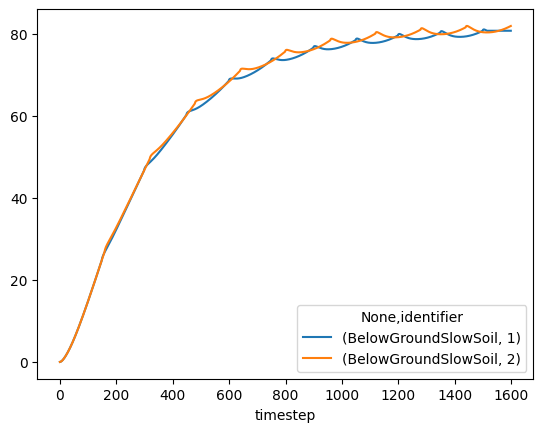

In [4]:
spinup_results.pools.to_pandas()[["identifier", "timestep", "BelowGroundSlowSoil"]].pivot(index="timestep", columns="identifier").plot()

<Axes: xlabel='timestep'>

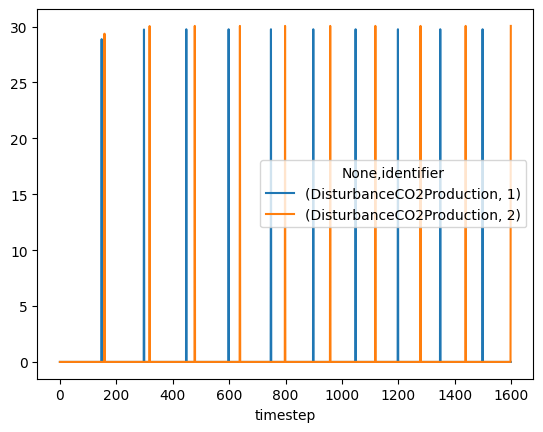

In [5]:
spinup_results.flux.to_pandas()[["identifier", "timestep", "DisturbanceCO2Production"]].pivot(index="timestep", columns="identifier").plot()

In [6]:
# examine the state variables for stand identifer 1
state = spinup_results.state.to_pandas()
state[state.identifier==1].set_index("timestep").head()

,identifier,spinup_state,slow_pools,disturbance_type,rotation,step,last_rotation_slow_C,enabled,age,growth_enabled
timestep,,,,,,,,,,
0,1,0,0.011447,-1,0,1,0.0,1,1,1
1,1,0,0.049556,-1,0,2,0.0,1,2,1
2,1,0,0.119076,-1,0,3,0.0,1,3,1
3,1,0,0.220668,-1,0,4,0.0,1,4,1
4,1,0,0.353122,-1,0,5,0.0,1,5,1
